## 1. Configuração do ambiente

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [85]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [86]:
# bibliotecas para machine learning
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## 2. Carregando o dataset
### Esquema das variáveis conforme o Kaggle
- Customers who left within the last month: the column is called Churn

- Services that each customer has signed up for: phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

- Customer account information: how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

- Demographic info about customers: gender, age range, and if they have partners and dependents

In [ ]:
# define o caminho
path = '../../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# carrega os dados
df = pd.read_csv(path)

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do dataset:")
df.head()

Shape dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [88]:
# informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===")
df.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Análise Exploratória de Dados (EDA)
### 3.1 Análise de Missing Values
**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

=== ANÁLISE DE MISSING VALUES ===
                    Coluna  Missing_Count  Missing_Percentage
TotalCharges  TotalCharges             11                0.16


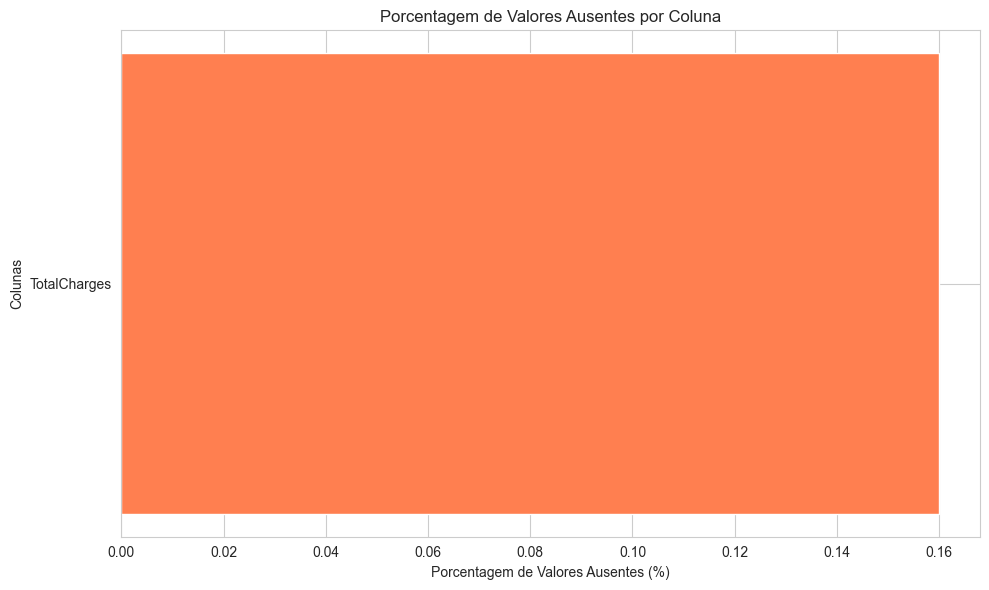

In [89]:
print("=== ANÁLISE DE MISSING VALUES ===")

# transformar total charges para numérico float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_values = pd.DataFrame({
    "Coluna": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values["Missing_Count"] > 0].sort_values(by="Missing_Percentage", ascending=False)

if len(missing_values) > 0:
    print(missing_values)

    plt.figure(figsize=(10,6))
    plt.barh(missing_values["Coluna"], missing_values["Missing_Percentage"], color='coral')
    plt.xlabel('Porcentagem de Valores Ausentes (%)')
    plt.ylabel('Colunas')
    plt.title('Porcentagem de Valores Ausentes por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna possui valores ausentes.")

### 3.2 Análise da Variável Target
**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===
Contagem de cada classe:
target
0    5174
1    1869
Name: count, dtype: int64

Porcentagem de cada classe:
No Churn: 73.46%
Churn: 26.54%


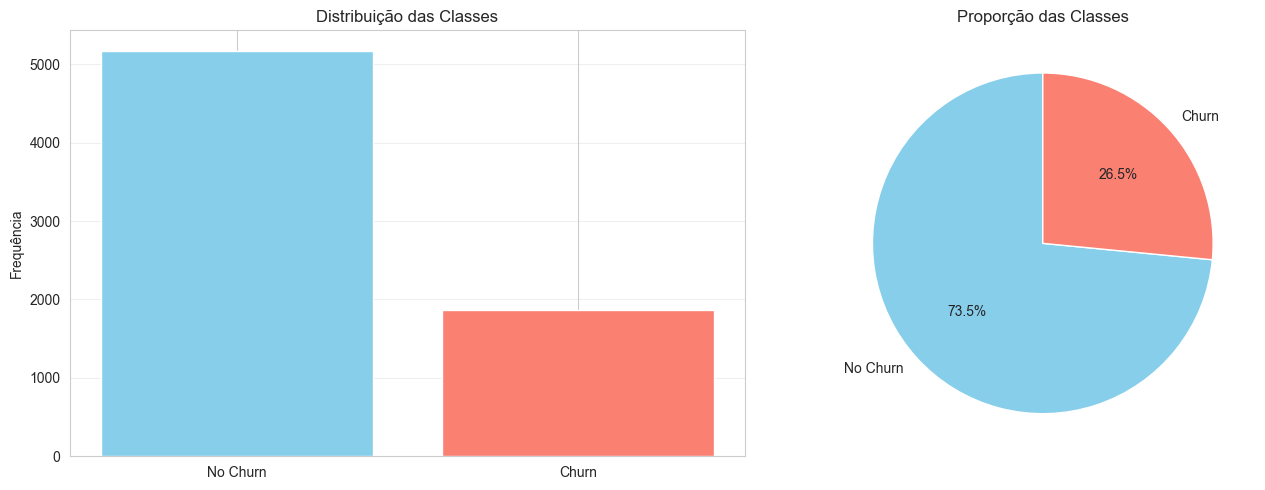


Ratio de desbalanceamento: 0.36
Variável desbalanceada


In [90]:
# renomear a variável target para target
df.rename(columns={'Churn': 'target'}, inplace=True)

# converter target para binário (Yes = 1, No = 0)
df['target'] = df['target'].map({'Yes': 1, 'No': 0}).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem de cada classe:")
print(target_counts)
print("\nPorcentagem de cada classe:")
for idx, pct in target_percentages.items():
    label = 'Churn' if idx == 1 else 'No Churn'
    print(f"{label}: {pct:.2f}%")

# vizualização da distribuição da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grafico de barras
axes[0].bar(["No Churn", "Churn"], target_counts, color=['skyblue', 'salmon'])
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das Classes")
axes[0].grid(axis='y', alpha=0.3)

# grafico de setores
axes[1].pie(target_counts.values, labels=["No Churn", "Churn"], 
            autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
axes[1].set_title("Proporção das Classes")

plt.tight_layout()
plt.show()

# avaliar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de desbalanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Variável desbalanceada")
else:
    print("Variável razoavelmente balanceada")

A variável alvo (target) indica se houve ou não churn. Na visualização, vemos 1869 casos de churn (26,54%) e 5174 no churn (73,46%), o que mostra uma predominância da classe negativa; o ratio entre as classes é de aproximadamente 0,36, indicando um desbalanceamento entre as classes. Isso significa que devemos utilizar a divisão estratificada e técnicas como SMOTE.

### 3.3 Análise de Outliers
**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos:**
- **Z-Score:** Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização:** Boxplots para identificação visual

In [91]:
df.select_dtypes(include=[np.number]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'target'], dtype='object')

In [92]:
# df head com todas as colunas
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


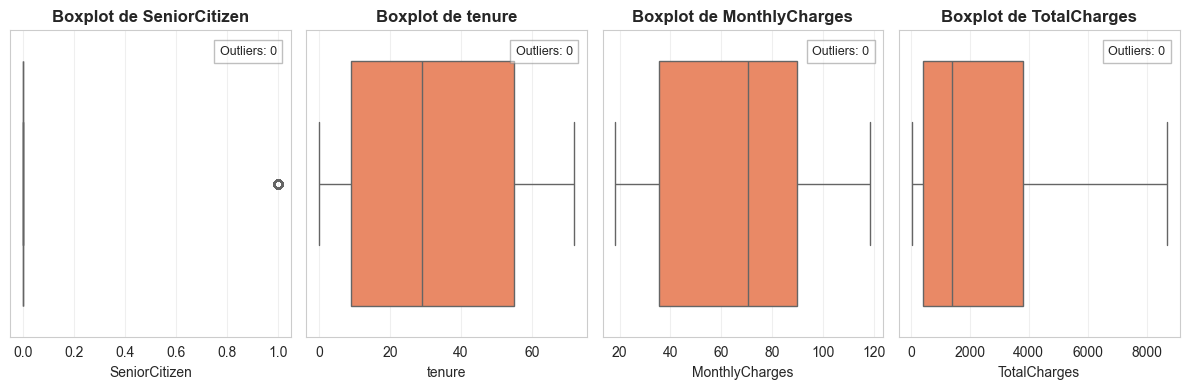

In [93]:
# colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('target')

n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows * 4))

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f"Boxplot de {col}",fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
    
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


**Resultados:**
As variáveis não apresentam outliers, tanto pelo boxplot quanto pelo z-score. Por exemplo, tenure não possui outliers estatísticos (z-score > 3) e o boxplot não mostra pontos extremos.

**Conclusão:**
Os dados estão bem distribuídos, sem outliers em tenure, SeniorCitizen e MonthlyCharges. Técnicas simples como capping são suficientes para tratamento, sem necessidade de remoção agressiva.

### 3.4 Análise de Distribuições
**Objetivo:** Entender a distribuição das variáveis numéricas para identificarmos as possíveis assimetrias

In [94]:
distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita') if skewness > 0 else 'Assimétrica à esquerda'
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

        Coluna  Skewness  Kurtosis         Interpretação
 SeniorCitizen     1.834     1.363 Assimétrica à direita
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal
  TotalCharges     0.962    -0.232 Assimétrica à direita


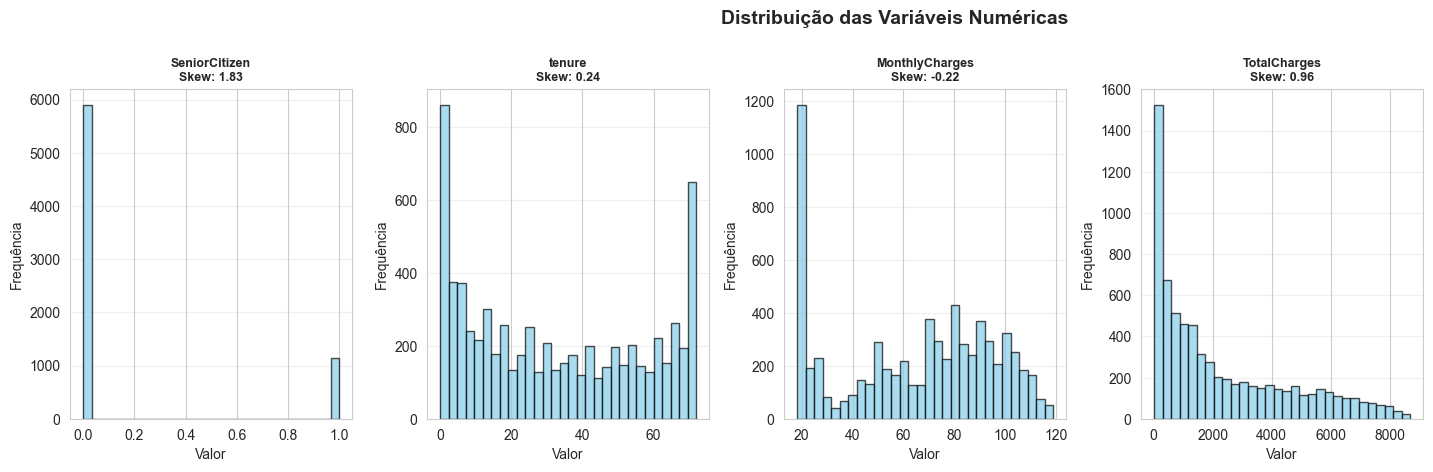

In [95]:
# visualização da distribuição das variáveis numéricas
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}',fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)
    
# remove subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [96]:
# preenche totalcharges nulo com a mediana
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# cria coluna de diferenca de total charges e monthly charges
df['ChargeDiff'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

# filtra apenas charges diff > 0 para análise
df[df['ChargeDiff'] > 0]

C:\Users\gfrei\AppData\Local\Temp\ipykernel_22728\1549364321.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target,ChargeDiff
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.45
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,10.25
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,23.30
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0,4.40
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,111.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7026,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,1,5.55
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,Yes,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,0,16.10
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,0,15.50
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,20.85


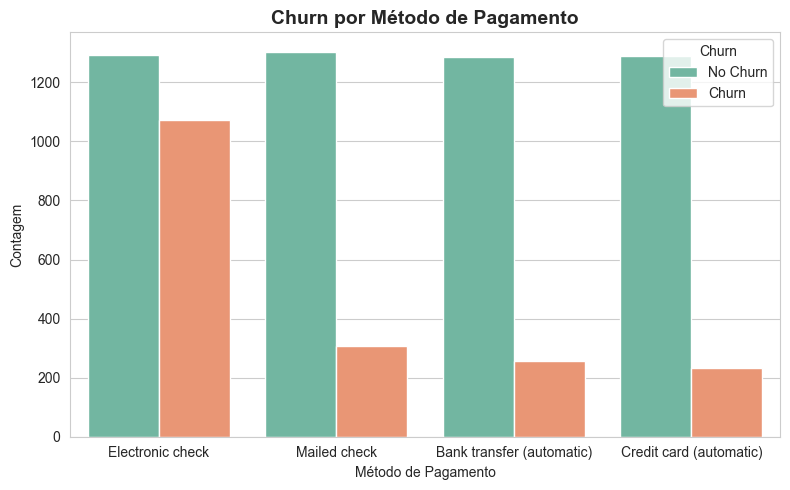

In [97]:
# análise de churn por tipo de pagamento (automático vs manual)
plt.figure(figsize=(8, 5))
sns.countplot(x='PaymentMethod', hue='target', data=df, palette='Set2')
plt.title('Churn por Método de Pagamento', fontsize=14, fontweight='bold')
plt.xlabel('Método de Pagamento')
plt.ylabel('Contagem')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

1. O método Electronic check (cheque eletrônico) é o principal ponto de atenção. É o único grupo onde o número de cancelamentos se aproxima significativamente do número de retenções.

- A taxa de churn neste grupo é visualmente muito superior à de qualquer outro método.

- Isso sugere uma possível fricção no processo de pagamento, uma experiência de usuário insatisfatória ou que este método é preferido por um perfil de cliente mais volátil.

2. Estabilidade nos Métodos Automáticos
Os métodos Bank transfer (automatic) e Credit card (automatic) apresentam o melhor desempenho em termos de retenção.

- Ambos possuem uma base de "No Churn" sólida (acima de 1200) e o menor volume de cancelamentos do gráfico.

- Isso reforça a tese de que pagamentos automatizados tendem a reduzir o churn involuntário (por esquecimento) e aumentam a fidelidade do cliente.

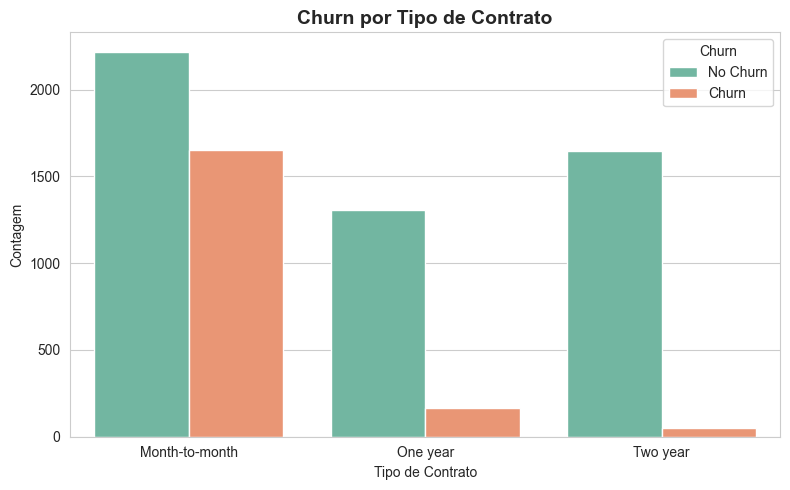

In [98]:
# análise de churn por tipo de contrato (# Contrato mensal é o maior preditor individual de churn)
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='target', data=df, palette='Set2')
plt.title('Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Contagem')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

1. O Risco do Contrato Mensal (Month-to-month)
Este é o cenário de maior vulnerabilidade para a empresa.

- Volume Massivo: É a categoria com o maior número total de clientes, mas também a que concentra a grande maioria dos cancelamentos.

- Proporção: O churn é alarmante nesta categoria, atingindo uma proporção visualmente próxima de 40% a 45% da base mensal. Clientes sem fidelidade contratual têm baixíssima barreira de saída.

2. O Impacto da Fidelização (One year & Two year)
À medida que o prazo do contrato aumenta, o churn cai drasticamente:

- One year: O número de cancelamentos reduz significativamente em comparação ao mensal. A estabilidade aumenta, sugerindo que o compromisso de 12 meses filtra clientes mais decididos ou oferece benefícios que justificam a permanência.

- Two year: Este é o cenário ideal de retenção. Embora tenha uma base total menor que a mensal, o churn é quase inexistente. Clientes que aceitam contratos de dois anos são os mais leais e apresentam o maior LTV (Lifetime Value).

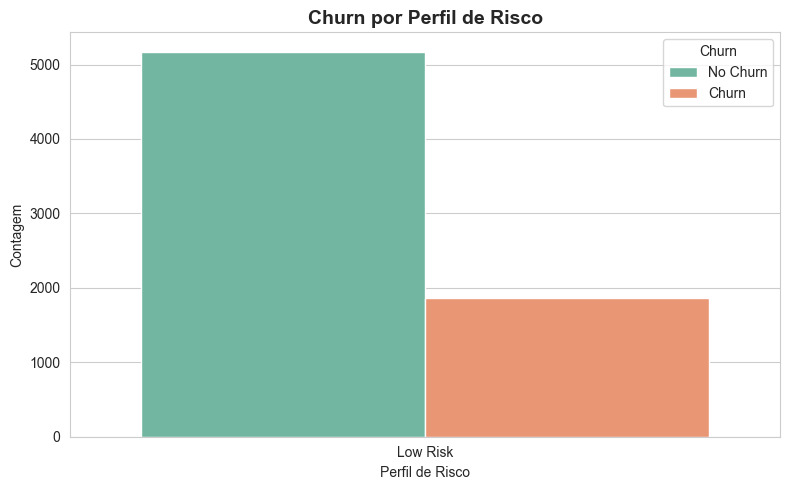

In [99]:
# análise de churn para Internet sem nenhum serviço adicional (perfil de risco) vs com algum tipo serviço adicional (perfil protegido)
internet_services = [
            "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies"
        ]
df['RiskProfile'] = np.where((df['InternetService'] != 'No') & (df[internet_services].sum(axis=1) == 0), 1, 0)
df['RiskProfile'] = df['RiskProfile'].map({1: 'High Risk', 0: 'Low Risk'})

plt.figure(figsize=(8, 5))
sns.countplot(x='RiskProfile', hue='target', data=df, palette='Set2')
plt.title('Churn por Perfil de Risco', fontsize=14, fontweight='bold')
plt.xlabel('Perfil de Risco')
plt.ylabel('Contagem')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

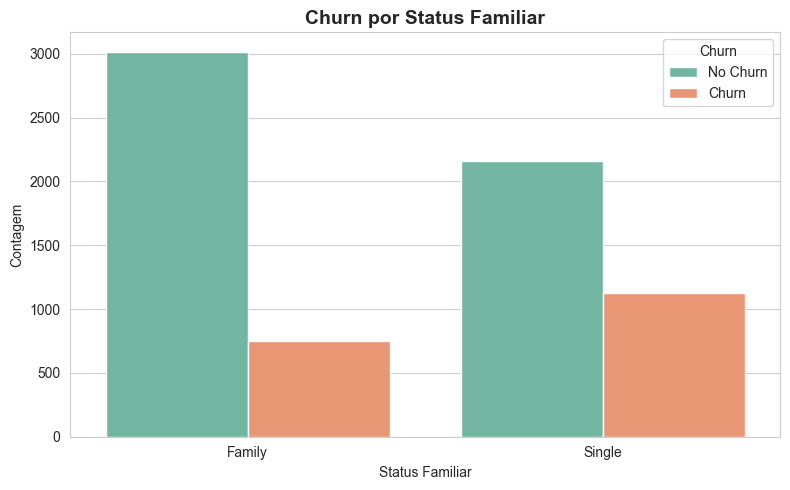

In [100]:
# análise do churn cliente sem parceiro e sem dependentes vs cliente com parceiro ou com dependentes
df['FamilyStatus'] = np.where((df['Partner'] == 'No') & (df['Dependents'] == 'No'), 'Single', 'Family')
plt.figure(figsize=(8, 5))
sns.countplot(x='FamilyStatus', hue='target', data=df, palette='Set2')
plt.title('Churn por Status Familiar', fontsize=14, fontweight='bold')
plt.xlabel('Status Familiar')
plt.ylabel('Contagem')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

1. Clientes "Single": Maior Propensão ao Churn
- O grupo de solteiros apresenta uma taxa de cancelamento proporcionalmente muito superior à do grupo familiar.

- Volume de Churn: Embora a base total de "Single" seja menor do que a de "Family", o número absoluto de cancelamentos é visivelmente maior (superando 1000 registros).

- Proporção: Aproximadamente 1 em cada 3 clientes solteiros cancela o serviço, o que indica uma volatilidade maior desse perfil.

2. Clientes "Family": Maior Estabilidade e Retenção
- O grupo familiar demonstra ser um porto seguro para a retenção da empresa.

- Fidelidade: A barra de "No Churn" é a mais alta de todo o estudo até agora (atingindo a marca de 3000).

- Segurança: O churn é significativamente menor em proporção à base total. Isso geralmente ocorre porque serviços contratados para a família (como internet residencial ou planos de streaming) envolvem a dependência de várias pessoas, tornando a decisão de cancelamento mais complexa e menos impulsiva.

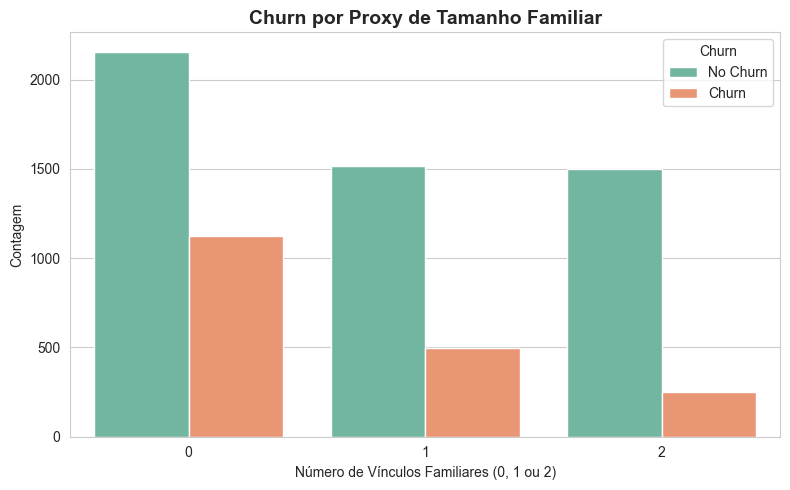

In [101]:
# análise do churn por Proxy de tamanho familiar (0, 1 ou 2 vínculos)
df['FamilySizeProxy'] = df[['Partner', 'Dependents']].apply(lambda x: (x == 'Yes').sum(), axis=1)
plt.figure(figsize=(8, 5))
sns.countplot(x='FamilySizeProxy', hue='target', data=df, palette='Set2')
plt.title('Churn por Proxy de Tamanho Familiar', fontsize=14, fontweight='bold')
plt.xlabel('Número de Vínculos Familiares (0, 1 ou 2)')
plt.ylabel('Contagem')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

1. Zero Vínculos: O Cenário Crítico
- Clientes com 0 vínculos (provavelmente solteiros e sem dependentes) representam o maior volume de dados e o maior risco.

- A taxa de churn é visivelmente alta, com a barra laranja ultrapassando a marca de 1000.

- Isso valida a análise anterior: quanto menor o núcleo familiar conectado ao serviço, maior a facilidade de cancelamento.

2. Um Vínculo: O Equilíbrio
- Clientes com 1 vínculo (como um parceiro ou um único dependente) mostram uma melhora drástica na retenção.

- O churn cai para menos da metade em comparação ao grupo zero.

- Este grupo mantém uma base de retenção sólida (barras verdes) em torno de 1500.

3. Dois Vínculos: A Fidelização Máxima
- Clientes com 2 vínculos (núcleo familiar completo) são os mais leais.

- Embora a base de clientes seja similar em tamanho ao grupo de 1 vínculo, o churn é o menor de todo o gráfico (abaixo de 250).

- A proporção de cancelamento aqui é mínima, sugerindo que o serviço está profundamente integrado à rotina de várias pessoas na residência.

In [102]:
# Combinação de risco: boleto eletrônico + sem papel
df['RiskCombo'] = np.where((df['PaymentMethod'] == 'Electronic check') & (df['PaperlessBilling'] == 'Yes'), 1, 0)

# Bundle de segurança/suporte
df['SupportBundle'] = np.where((df['TechSupport'] == 'Yes') & (df['OnlineSecurity'] == 'Yes'), 1, 0)

### 3.5 Análise de Correlações Lineares
**Objetivo:** Identificar relações lineares entre variáveis e detectar multicolinearidade

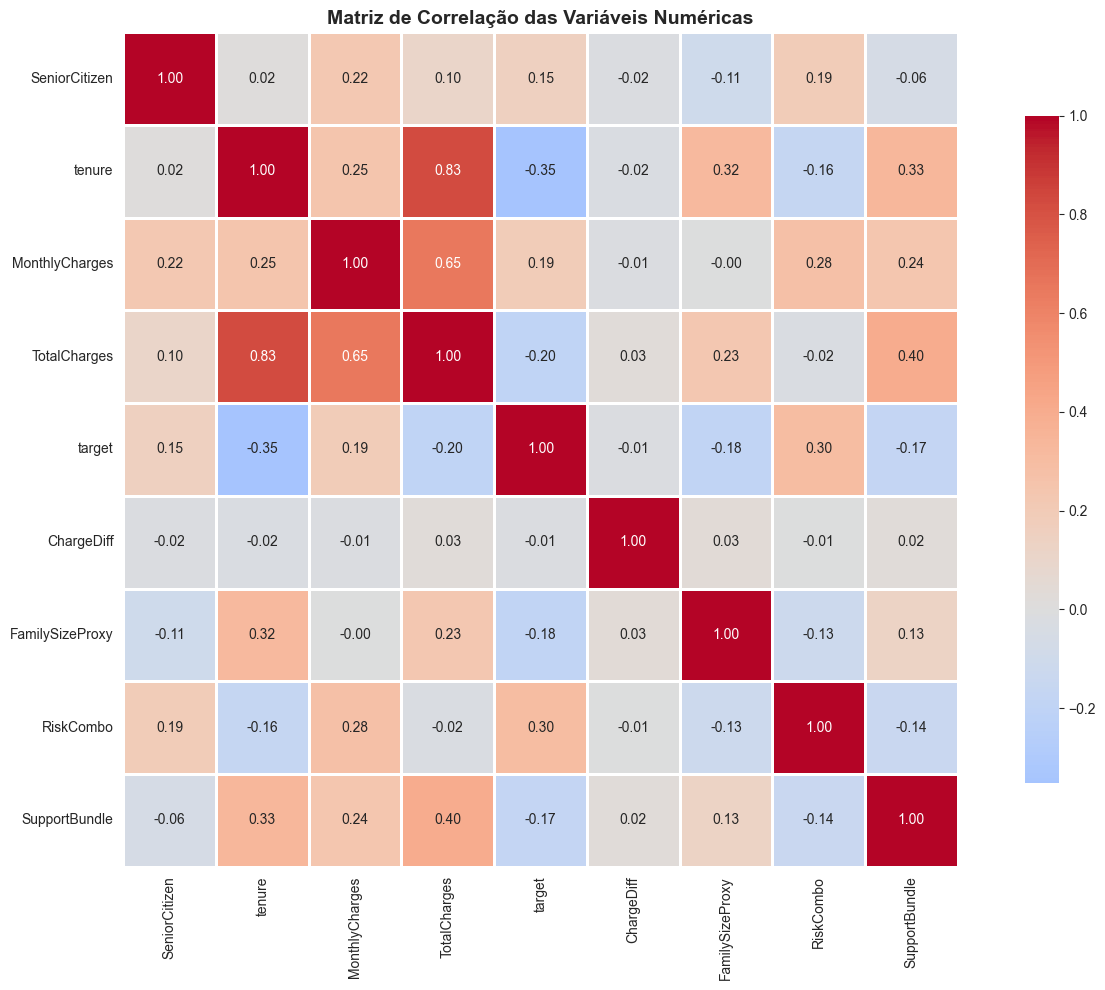

target             1.000000
RiskCombo          0.301646
MonthlyCharges     0.193356
SeniorCitizen      0.150889
ChargeDiff        -0.014850
SupportBundle     -0.170707
FamilySizeProxy   -0.184193
TotalCharges      -0.199037
tenure            -0.352229
Name: target, dtype: float64
Feature 1    Feature 2  Correlation
   tenure TotalCharges        0.825
Alta correlação linear entre as features


In [103]:
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# visualização
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# identificar correlações fortes com target
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# identificar pares de features com alta correlação (possiveis multicolinearidades)
high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlation': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("Alta correlação linear entre as features")
else:
    print("Nenhuma correlação linear alta entre as features")


In [104]:
# preenchimento dos valores NaN com 0

### 4.2 Codificação de Variáveis Categóricas (One-hot Encoding)
Para que algoritmos de machine learning possam trabalhar com variáveis categóricas, é necessário convertê-las em formato numérico. O método mais comum é o One-hot Encoding, que transforma cada categoria em uma coluna binária (0 ou 1).

**Passos:**

- Identifique as colunas categóricas relevantes (ex.: sex, cp, restecg, slope, thal, dataset).
- Aplique o pd.get_dummies() para criar as variáveis dummies.
- Evite a duplicidade de informação removendo uma categoria de cada variável (drop_first=True), se necessário.

**Observações:**

- O One-hot Encoding aumenta o número de colunas, mas permite que modelos interpretem corretamente as categorias.
- Após a codificação, utilize o novo dataframe (df_encoded) para as etapas de modelagem.

In [105]:
df_clean = df.copy()

# one hot encoding das variaveis categoricas relevantes
categorial_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", 
                   "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", 
                   "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
                   "RiskCombo", "SupportBundle", "FamilySizeProxy","FamilyStatus","RiskProfile"]
df_encoded = pd.get_dummies(df_clean, columns=categorial_cols, drop_first=True)

print(f'Shape após o One-Hot encoding: {df_encoded.shape}')
df_encoded.head()

Shape após o One-Hot encoding: (7043, 38)


,customerID,tenure,MonthlyCharges,TotalCharges,target,ChargeDiff,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,RiskCombo_1,SupportBundle_1,FamilySizeProxy_1,FamilySizeProxy_2,FamilyStatus_Single
0,7590-VHVEG,1,29.85,29.85,0,0.00,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False
1,5575-GNVDE,34,56.95,1889.50,0,-46.80,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,1,0.45,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True
3,7795-CFOCW,45,42.30,1840.75,0,-62.75,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True
4,9237-HQITU,2,70.70,151.65,1,10.25,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,True


## 4. MVP
Utiliza o modelo Logistic Regression o class_weight como técnica para balanceamento de classes

In [109]:
# divisão dos dados de treino e teste
from sklearn.model_selection import train_test_split

# remove colunas não numéricas que não devem entrar no modelo
cols_to_drop = ['customerID', 'target']
X = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns], axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# treina o modelo de regressão logística com o parâmetro class_weight='balanced' e seed=42
lr_model = LogisticRegression(class_weight='balanced', random_state=42, penalty='l2')
lr_model.fit(X_train, y_train)

# faz previsões no conjunto de teste
y_pred = lr_model.predict(X_test)

# avalia o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.7601
F1 Score: 0.6427
Precision: 0.5305
Recall: 0.8150


c:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    http

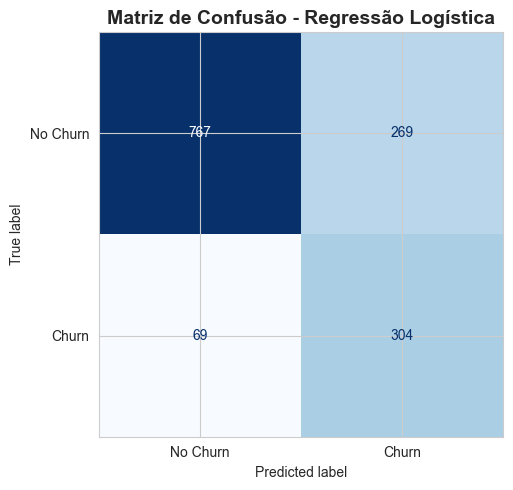

In [113]:
# matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])

# plot sem linhas de grade
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Matriz de Confusão - Regressão Logística', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [108]:
"""
-> Gabriel
churn_prediction.py
config.py
data_cleaner.py
data_loader.py
feature_engineering.py
main.py
pipeline.py
MVP (regressao logistica e arvore de decisao)

-> Diego
estrutura do projeto
ML Canvas (/docs)
versionamento do código git
"""

'\n-> Gabriel\nchurn_prediction.py\nconfig.py\ndata_cleaner.py\ndata_loader.py\nfeature_engineering.py\nmain.py\npipeline.py\nMVP (regressao logistica e arvore de decisao)\n\n-> Diego\nestrutura do projeto\nML Canvas (/docs)\nversionamento do código git\n'